In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load all 9 CSV files
# -------------------------

caius_rate = pd.read_csv("caius_ripple_summary.csv")
caius_duration = pd.read_csv("caius_duration_summary.csv")
caius_amplitude = pd.read_csv("caius_amplitude_summary.csv")

embry_rate = pd.read_csv("embry_ripple_summary.csv")
embry_duration = pd.read_csv("embry_duration_summary.csv")
embry_amplitude = pd.read_csv("embry_amplitude_summary.csv")

marcus_rate = pd.read_csv("marcus_ripple_rate_avg.csv")
marcus_duration = pd.read_csv("marcus_duration_avg.csv")
marcus_amplitude = pd.read_csv("marcus_amplitude_avg.csv")

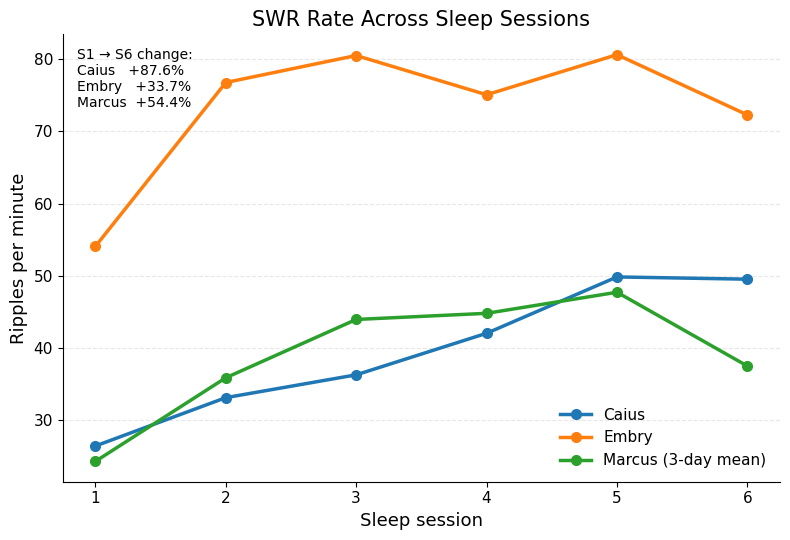

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5.5))

plt.plot(
    caius_rate["session_number"],
    caius_rate["ripples_per_min"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Caius"
)

plt.plot(
    embry_rate["session_number"],
    embry_rate["ripples_per_min"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Embry"
)

plt.plot(
    marcus_rate["session_number"],
    marcus_rate["ripples_per_min"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Marcus (3-day mean)"
)

plt.xlabel("Sleep session", fontsize=13)
plt.ylabel("Ripples per minute", fontsize=13)
plt.title("SWR Rate Across Sleep Sessions", fontsize=15)

plt.xticks([1, 2, 3, 4, 5, 6], fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# S1 → S6 percentage change
plt.text(
    0.02, 0.97,
    "S1 → S6 change:\n"
    "Caius   +87.6%\n"
    "Embry   +33.7%\n"
    "Marcus  +54.4%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt

animals = ["Caius", "Embry", "Marcus"]

s1 = [
    caius_rate.loc[caius_rate["session_number"] == 1, "ripples_per_min"].iloc[0],
    embry_rate.loc[embry_rate["session_number"] == 1, "ripples_per_min"].iloc[0],
    marcus_rate.loc[marcus_rate["session_number"] == 1, "ripples_per_min"].iloc[0]
]

s6 = [
    caius_rate.loc[caius_rate["session_number"] == 6, "ripples_per_min"].iloc[0],
    embry_rate.loc[embry_rate["session_number"] == 6, "ripples_per_min"].iloc[0],
    marcus_rate.loc[marcus_rate["session_number"] == 6, "ripples_per_min"].iloc[0]
]

percent_change = [
    (b - a) / a * 100
    for a, b in zip(s1, s6)
]

for animal, a, b, change in zip(animals, s1, s6, percent_change):
    print(f"{animal}: S1={a:.2f}, S6={b:.2f}, change={change:+.1f}%")

Caius: S1=26.40, S6=49.52, change=+87.6%
Embry: S1=54.07, S6=72.29, change=+33.7%
Marcus: S1=24.27, S6=37.48, change=+54.4%


Caius: S1=71.00, S6=84.00, change=+18.3%
Embry: S1=87.97, S6=79.27, change=-9.9%
Marcus: S1=77.45, S6=112.98, change=+45.9%


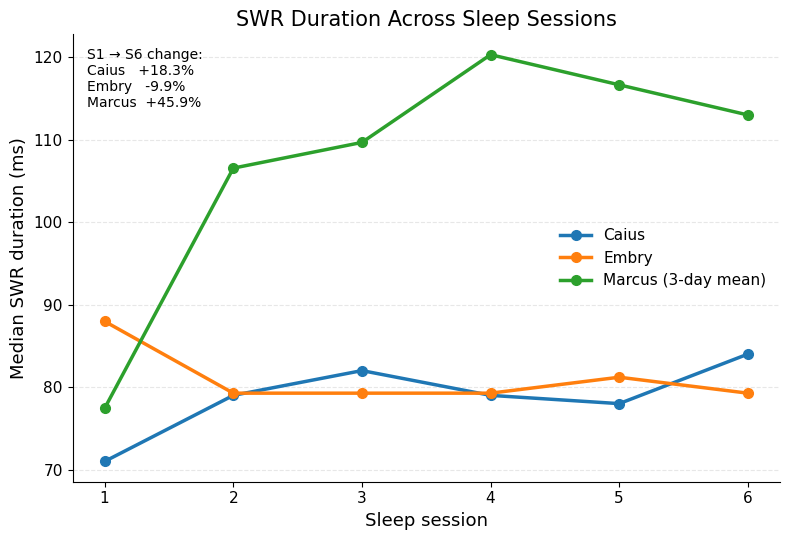

In [14]:
import matplotlib.pyplot as plt

# Calculate S1 -> S6 percentage change
caius_s1 = caius_duration.loc[
    caius_duration["session_number"] == 1, "median"
].iloc[0]
caius_s6 = caius_duration.loc[
    caius_duration["session_number"] == 6, "median"
].iloc[0]

embry_s1 = embry_duration.loc[
    embry_duration["session_number"] == 1, "median"
].iloc[0]
embry_s6 = embry_duration.loc[
    embry_duration["session_number"] == 6, "median"
].iloc[0]

marcus_s1 = marcus_duration.loc[
    marcus_duration["session_number"] == 1, "median"
].iloc[0]
marcus_s6 = marcus_duration.loc[
    marcus_duration["session_number"] == 6, "median"
].iloc[0]

caius_change = (caius_s6 - caius_s1) / caius_s1 * 100
embry_change = (embry_s6 - embry_s1) / embry_s1 * 100
marcus_change = (marcus_s6 - marcus_s1) / marcus_s1 * 100

print(f"Caius: S1={caius_s1:.2f}, S6={caius_s6:.2f}, change={caius_change:+.1f}%")
print(f"Embry: S1={embry_s1:.2f}, S6={embry_s6:.2f}, change={embry_change:+.1f}%")
print(f"Marcus: S1={marcus_s1:.2f}, S6={marcus_s6:.2f}, change={marcus_change:+.1f}%")

# Plot
plt.figure(figsize=(8, 5.5))

plt.plot(
    caius_duration["session_number"],
    caius_duration["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Caius"
)

plt.plot(
    embry_duration["session_number"],
    embry_duration["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Embry"
)

plt.plot(
    marcus_duration["session_number"],
    marcus_duration["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Marcus (3-day mean)"
)

plt.xlabel("Sleep session", fontsize=13)
plt.ylabel("Median SWR duration (ms)", fontsize=13)
plt.title("SWR Duration Across Sleep Sessions", fontsize=15)

plt.xticks([1, 2, 3, 4, 5, 6], fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# S1 -> S6 change
plt.text(
    0.02, 0.97,
    "S1 → S6 change:\n"
    f"Caius   {caius_change:+.1f}%\n"
    f"Embry   {embry_change:+.1f}%\n"
    f"Marcus  {marcus_change:+.1f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

Caius: S1=4.60, S6=4.42, change=-3.8%
Embry: S1=4.28, S6=4.16, change=-2.8%
Marcus: S1=3.97, S6=4.46, change=+12.4%


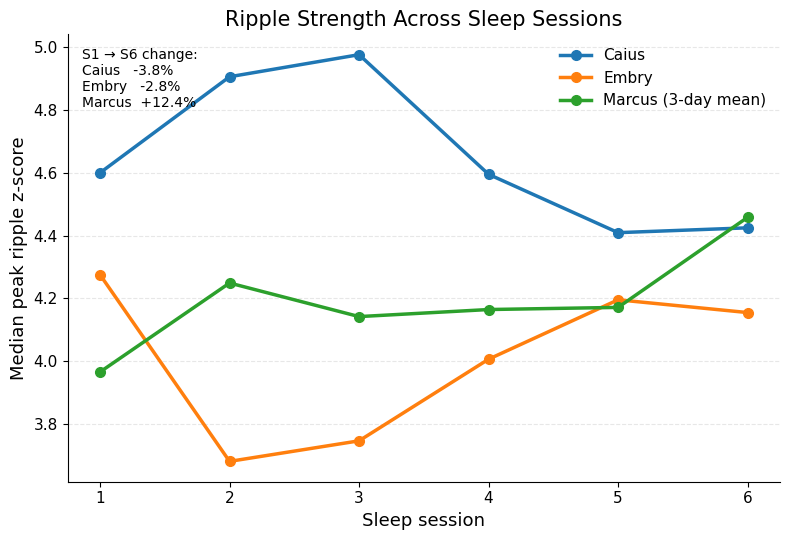

In [15]:
import matplotlib.pyplot as plt

# Calculate S1 -> S6 percentage change
caius_s1 = caius_amplitude.loc[
    caius_amplitude["session_number"] == 1, "median"
].iloc[0]
caius_s6 = caius_amplitude.loc[
    caius_amplitude["session_number"] == 6, "median"
].iloc[0]

embry_s1 = embry_amplitude.loc[
    embry_amplitude["session_number"] == 1, "median"
].iloc[0]
embry_s6 = embry_amplitude.loc[
    embry_amplitude["session_number"] == 6, "median"
].iloc[0]

marcus_s1 = marcus_amplitude.loc[
    marcus_amplitude["session_number"] == 1, "median"
].iloc[0]
marcus_s6 = marcus_amplitude.loc[
    marcus_amplitude["session_number"] == 6, "median"
].iloc[0]

caius_change = (caius_s6 - caius_s1) / caius_s1 * 100
embry_change = (embry_s6 - embry_s1) / embry_s1 * 100
marcus_change = (marcus_s6 - marcus_s1) / marcus_s1 * 100

print(f"Caius: S1={caius_s1:.2f}, S6={caius_s6:.2f}, change={caius_change:+.1f}%")
print(f"Embry: S1={embry_s1:.2f}, S6={embry_s6:.2f}, change={embry_change:+.1f}%")
print(f"Marcus: S1={marcus_s1:.2f}, S6={marcus_s6:.2f}, change={marcus_change:+.1f}%")

# Plot
plt.figure(figsize=(8, 5.5))

plt.plot(
    caius_amplitude["session_number"],
    caius_amplitude["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Caius"
)

plt.plot(
    embry_amplitude["session_number"],
    embry_amplitude["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Embry"
)

plt.plot(
    marcus_amplitude["session_number"],
    marcus_amplitude["median"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Marcus (3-day mean)"
)

plt.xlabel("Sleep session", fontsize=13)
plt.ylabel("Median peak ripple z-score", fontsize=13)
plt.title("Ripple Strength Across Sleep Sessions", fontsize=15)

plt.xticks([1, 2, 3, 4, 5, 6], fontsize=11)
plt.yticks(fontsize=11)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# S1 -> S6 change
plt.text(
    0.02, 0.97,
    "S1 → S6 change:\n"
    f"Caius   {caius_change:+.1f}%\n"
    f"Embry   {embry_change:+.1f}%\n"
    f"Marcus  {marcus_change:+.1f}%",
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

caius = pd.read_csv("caius_online_offline_stats.csv")
embry = pd.read_csv("embry_online_offline_stats.csv")
marcus = pd.read_csv("marcus_online_offline_stats.csv")

In [3]:
caius["animal"] = "Caius"
embry["animal"] = "Embry"
marcus["animal"] = "Marcus"

In [4]:
all_animals = pd.concat(
    [caius, embry, marcus],
    ignore_index=True
)

all_animals

,session,offline_swr,online_detection,TP,FN,capture_pct,missed_pct,animal,session_number,online_capture_pct,offline_missed_pct
0,01_s1,1055,0,0,1055,0.000000,100.000000,Caius,NaN,NaN,NaN
1,03_s2,1323,1971,917,406,69.312169,30.687831,Caius,NaN,NaN,NaN
2,05_s3,1449,1814,1073,376,74.051070,25.948930,Caius,NaN,NaN,NaN
3,07_s4,1722,2341,1232,490,71.544715,28.455285,Caius,NaN,NaN,NaN
4,09_s5,1996,2672,609,1387,30.511022,69.488978,Caius,NaN,NaN,NaN
5,11_s6,2029,2967,753,1276,37.111878,62.888122,Caius,NaN,NaN,NaN
6,01_s1,2157,2,0,2157,0.000000,100.000000,Embry,NaN,NaN,NaN
7,03_s2,3079,2732,2229,850,72.393634,27.606366,Embry,NaN,NaN,NaN
8,05_s3,3223,2489,1982,1241,61.495501,38.504499,Embry,NaN,NaN,NaN
9,07_s4,3000,2248,1963,1037,65.433333,34.566667,Embry,NaN,NaN,NaN


In [5]:
import pandas as pd
import numpy as np

# --------------------------------------------------
# Make one consistent capture/missed column
# --------------------------------------------------
all_animals["capture_pct_final"] = (
    all_animals["capture_pct"]
    .fillna(all_animals["online_capture_pct"])
)

all_animals["missed_pct_final"] = (
    all_animals["missed_pct"]
    .fillna(all_animals["offline_missed_pct"])
)

# --------------------------------------------------
# Session number
# --------------------------------------------------
all_animals["session_number"] = (
    all_animals["session"]
    .str.extract(r"_s(\d+)")[0]
    .astype(int)
)

# --------------------------------------------------
# Clean table
# --------------------------------------------------
final_stats = all_animals[
    [
        "animal",
        "session_number",
        "session",
        "offline_swr",
        "online_detection",
        "TP",
        "FN",
        "capture_pct_final",
        "missed_pct_final"
    ]
].copy()

final_stats.columns = [
    "Animal",
    "Session",
    "Session_name",
    "Offline_SWRS",
    "Online_detections",
    "TP",
    "FN",
    "Capture_pct",
    "Missed_pct"
]

final_stats

,Animal,Session,Session_name,Offline_SWRS,Online_detections,TP,FN,Capture_pct,Missed_pct
0,Caius,1,01_s1,1055,0,0,1055,0.000000,100.000000
1,Caius,2,03_s2,1323,1971,917,406,69.312169,30.687831
2,Caius,3,05_s3,1449,1814,1073,376,74.051070,25.948930
3,Caius,4,07_s4,1722,2341,1232,490,71.544715,28.455285
4,Caius,5,09_s5,1996,2672,609,1387,30.511022,69.488978
5,Caius,6,11_s6,2029,2967,753,1276,37.111878,62.888122
6,Embry,1,01_s1,2157,2,0,2157,0.000000,100.000000
7,Embry,2,03_s2,3079,2732,2229,850,72.393634,27.606366
8,Embry,3,05_s3,3223,2489,1982,1241,61.495501,38.504499
9,Embry,4,07_s4,3000,2248,1963,1037,65.433333,34.566667


In [6]:
animal_means = (
    final_stats[
        final_stats["Session"] != 1
    ]
    .groupby("Animal")["Capture_pct"]
    .mean()
    .reset_index()
)

animal_means.columns = [
    "Animal",
    "Mean_capture_S2_S6"
]

animal_means["Mean_capture_S2_S6"] = (
    animal_means["Mean_capture_S2_S6"].round(1)
)

animal_means

,Animal,Mean_capture_S2_S6
0,Caius,56.5
1,Embry,69.1
2,Marcus,43.8


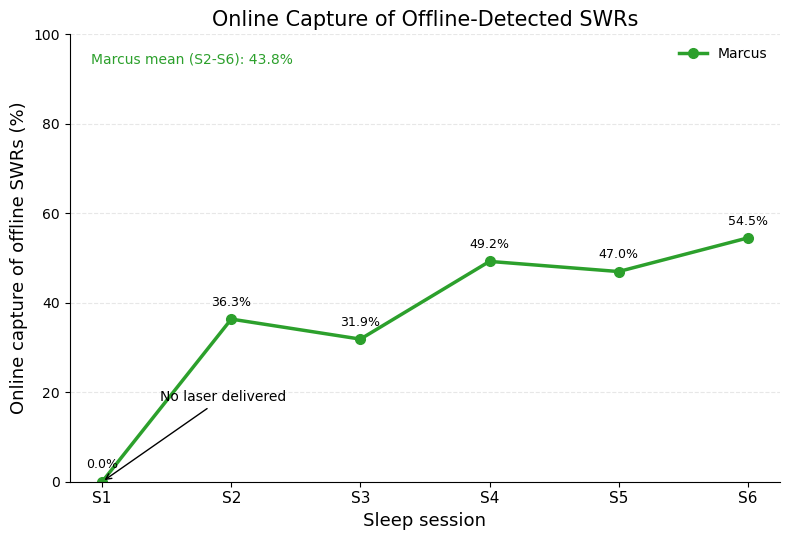

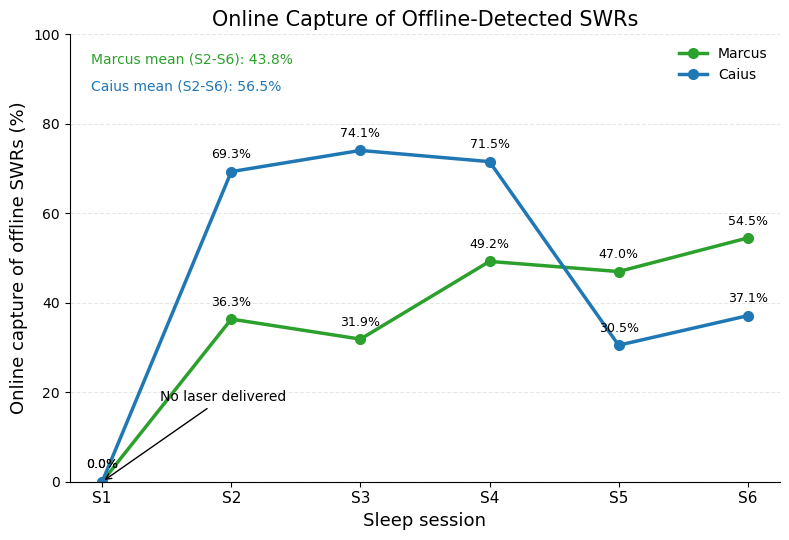

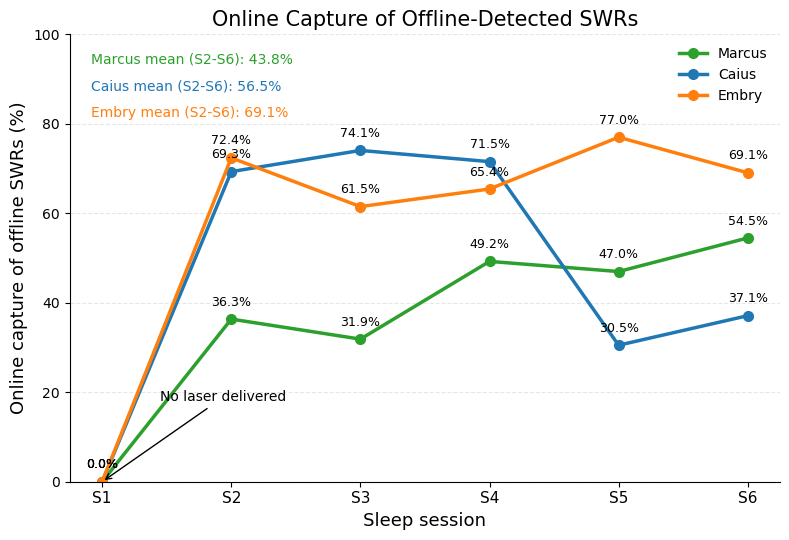

In [8]:
import matplotlib.pyplot as plt

# =====================================================
# Prepare data
# =====================================================

plot_data = final_stats.copy()

# Make sure session number is numeric
plot_data["Session"] = plot_data["Session"].astype(int)

# Pivot capture percentage
capture = plot_data.pivot(
    index="Animal",
    columns="Session",
    values="Capture_pct"
)

# =====================================================
# Colors
# =====================================================

animal_colors = {
    "Marcus": "tab:green",
    "Caius": "tab:blue",
    "Embry": "tab:orange"
}

# =====================================================
# Function to create plot
# =====================================================

def make_capture_plot(animals):

    fig, ax = plt.subplots(figsize=(8, 5.5))

    for i, animal in enumerate(animals):

        # Get S1-S6
        y = capture.loc[animal, [1, 2, 3, 4, 5, 6]]

        # Plot animal
        ax.plot(
            [1, 2, 3, 4, 5, 6],
            y,
            marker="o",
            markersize=7,
            linewidth=2.5,
            label=animal,
            color=animal_colors[animal]
        )

        # Mean capture excluding S1
        mean_capture = y.iloc[1:].mean()

        # Mean label in upper-left
        ax.text(
            0.03,
            0.96 - 0.06 * i,
            f"{animal} mean (S2-S6): {mean_capture:.1f}%",
            transform=ax.transAxes,
            fontsize=10,
            ha="left",
            va="top",
            color=animal_colors[animal]
        )

        # Percentage labels
        for x, value in zip(range(1, 7), y):

            ax.text(
                x,
                value + 3,
                f"{value:.1f}%",
                ha="center",
                fontsize=9
            )

    # =================================================
    # S1 annotation
    # =================================================

    ax.annotate(
        "No laser delivered",
        xy=(1, 0),
        xytext=(1.45, 18),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1
        ),
        fontsize=10
    )

    # =================================================
    # Axis labels
    # =================================================

    ax.set_xlabel(
        "Sleep session",
        fontsize=13
    )

    ax.set_ylabel(
        "Online capture of offline SWRs (%)",
        fontsize=13
    )

    ax.set_title(
        "Online Capture of Offline-Detected SWRs",
        fontsize=15
    )

    # =================================================
    # X axis
    # =================================================

    ax.set_xticks(
        [1, 2, 3, 4, 5, 6],
        ["S1", "S2", "S3", "S4", "S5", "S6"],
        fontsize=11
    )

    # =================================================
    # Y axis
    # =================================================

    ax.set_yticks(
        range(0, 101, 20)
    )

    ax.set_ylim(
        0,
        100
    )

    # =================================================
    # Grid
    # =================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # =================================================
    # Spines
    # =================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # =================================================
    # Legend
    # =================================================

    ax.legend(
        frameon=False,
        fontsize=10,
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()


# =====================================================
# Graph 1: Marcus only
# =====================================================

make_capture_plot(
    ["Marcus"]
)


# =====================================================
# Graph 2: Marcus + Caius
# =====================================================

make_capture_plot(
    ["Marcus", "Caius"]
)


# =====================================================
# Graph 3: Marcus + Caius + Embry
# =====================================================

make_capture_plot(
    ["Marcus", "Caius", "Embry"]
)

first pulse alignment

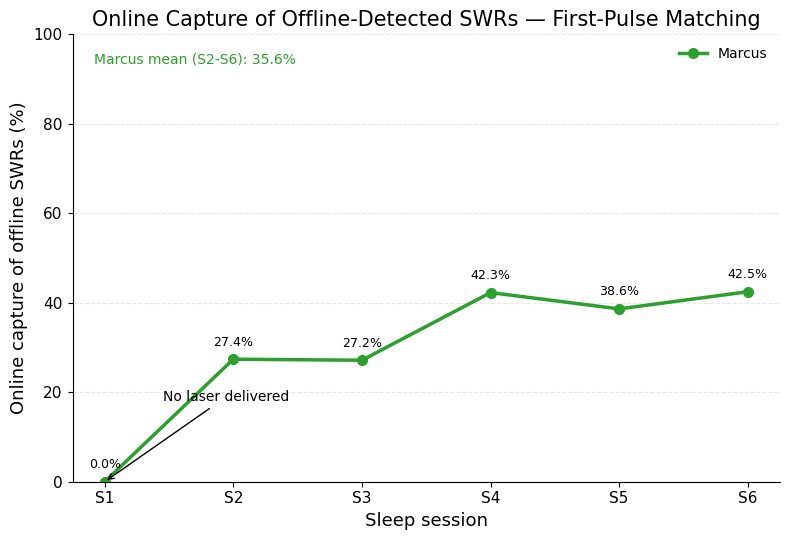

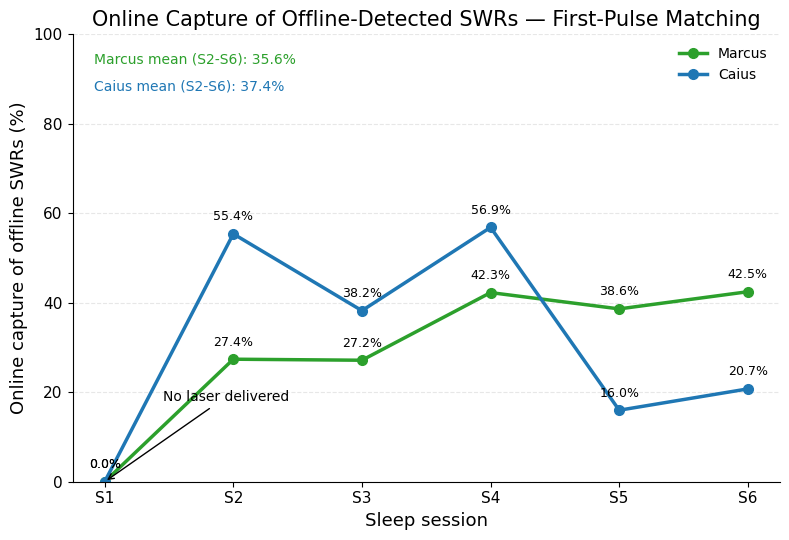

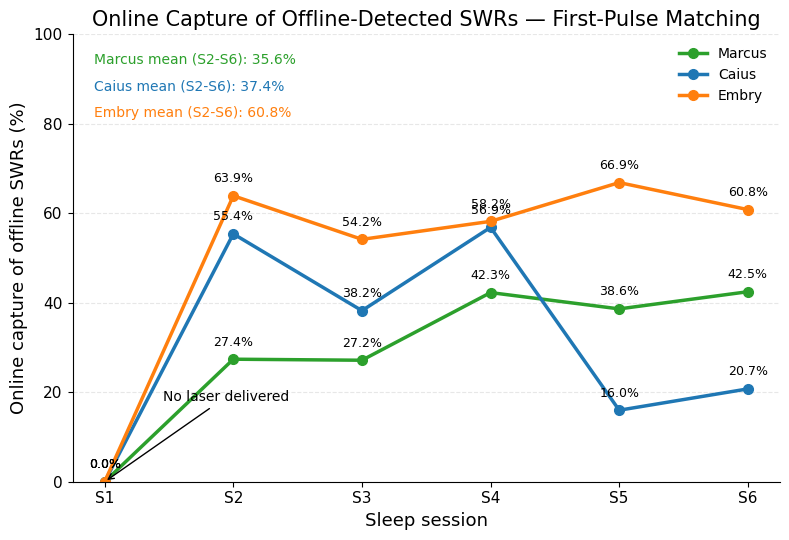

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Load first-pulse CSVs
# =====================================================

marcus_fp = pd.read_csv(
    "Marcus_first_pulse_online_offline_stats.csv"
)

caius_fp = pd.read_csv(
    "Caius_first_pulse_online_offline_stats.csv"
)

embry_fp = pd.read_csv(
    "Embry_first_pulse_online_offline_stats.csv"
)

# =====================================================
# Add animal labels
# =====================================================

marcus_fp["Animal"] = "Marcus"
caius_fp["Animal"] = "Caius"
embry_fp["Animal"] = "Embry"

# Make sure session numbers are integers
for df in [marcus_fp, caius_fp, embry_fp]:
    df["session_number"] = df["session_number"].astype(int)

# =====================================================
# Combine all animals
# =====================================================

all_firstpulse = pd.concat(
    [
        marcus_fp,
        caius_fp,
        embry_fp
    ],
    ignore_index=True
)

# =====================================================
# Pivot capture percentages
# =====================================================

capture_fp = all_firstpulse.pivot(
    index="Animal",
    columns="session_number",
    values="capture_pct_firstpulse"
)

# =====================================================
# Colors
# =====================================================

animal_colors = {
    "Marcus": "tab:green",
    "Caius": "tab:blue",
    "Embry": "tab:orange"
}

# =====================================================
# Plot function
# =====================================================

def make_firstpulse_plot(animals):

    fig, ax = plt.subplots(
        figsize=(8, 5.5)
    )

    for i, animal in enumerate(animals):

        # Get S1-S6
        y = capture_fp.loc[
            animal,
            [1, 2, 3, 4, 5, 6]
        ]

        # Plot
        ax.plot(
            [1, 2, 3, 4, 5, 6],
            y,
            marker="o",
            markersize=7,
            linewidth=2.5,
            label=animal,
            color=animal_colors[animal]
        )

        # Mean capture excluding S1
        mean_capture = y.iloc[1:].mean()

        # Mean label in upper-left
        ax.text(
            0.03,
            0.96 - 0.06 * i,
            f"{animal} mean (S2-S6): {mean_capture:.1f}%",
            transform=ax.transAxes,
            fontsize=10,
            ha="left",
            va="top",
            color=animal_colors[animal]
        )

        # Percentage labels
        for x, value in zip(
            range(1, 7),
            y
        ):

            ax.text(
                x,
                value + 3,
                f"{value:.1f}%",
                ha="center",
                fontsize=9
            )

    # =================================================
    # S1 annotation
    # =================================================

    ax.annotate(
        "No laser delivered",
        xy=(1, 0),
        xytext=(1.45, 18),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1
        ),
        fontsize=10
    )

    # =================================================
    # Labels
    # =================================================

    ax.set_xlabel(
        "Sleep session",
        fontsize=13
    )

    ax.set_ylabel(
        "Online capture of offline SWRs (%)",
        fontsize=13
    )

    ax.set_title(
        "Online Capture of Offline-Detected SWRs — First-Pulse Matching",
        fontsize=15
    )

    # =================================================
    # X axis
    # =================================================

    ax.set_xticks(
        [1, 2, 3, 4, 5, 6],
        ["S1", "S2", "S3", "S4", "S5", "S6"]
    )

    ax.tick_params(
        axis="x",
        labelsize=11
    )

    # =================================================
    # Y axis
    # =================================================

    ax.set_yticks(
        range(0, 101, 20)
    )

    ax.tick_params(
        axis="y",
        labelsize=11
    )

    ax.set_ylim(
        0,
        100
    )

    # =================================================
    # Grid
    # =================================================

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # =================================================
    # Spines
    # =================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # =================================================
    # Legend
    # =================================================

    ax.legend(
        frameon=False,
        fontsize=10,
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()


# =====================================================
# GRAPH 1 — Marcus only
# =====================================================

make_firstpulse_plot(
    ["Marcus"]
)


# =====================================================
# GRAPH 2 — Marcus + Caius
# =====================================================

make_firstpulse_plot(
    ["Marcus", "Caius"]
)


# =====================================================
# GRAPH 3 — Marcus + Caius + Embry
# =====================================================

make_firstpulse_plot(
    ["Marcus", "Caius", "Embry"]
)

In [15]:
# =====================================================
# Difference between matching methods
# Always positive
# =====================================================

comparison["Difference (percentage points)"] = (
    comparison["First-pulse mean (%)"]
    - comparison["Any-pulse mean (%)"]
).abs()

# =====================================================
# Round
# =====================================================

comparison[
    [
        "First-pulse mean (%)",
        "Any-pulse mean (%)",
        "Difference (percentage points)"
    ]
] = comparison[
    [
        "First-pulse mean (%)",
        "Any-pulse mean (%)",
        "Difference (percentage points)"
    ]
].round(1)

# =====================================================
# Reorder columns for PPT
# =====================================================

comparison = comparison[
    [
        "Animal",
        "First-pulse mean (%)",
        "Any-pulse mean (%)",
        "Difference (percentage points)"
    ]
]

comparison

,Animal,First-pulse mean (%),Any-pulse mean (%),Difference (percentage points)
0,Caius,37.4,56.5,19.1
1,Embry,60.8,69.1,8.3
2,Marcus,35.6,43.8,8.2


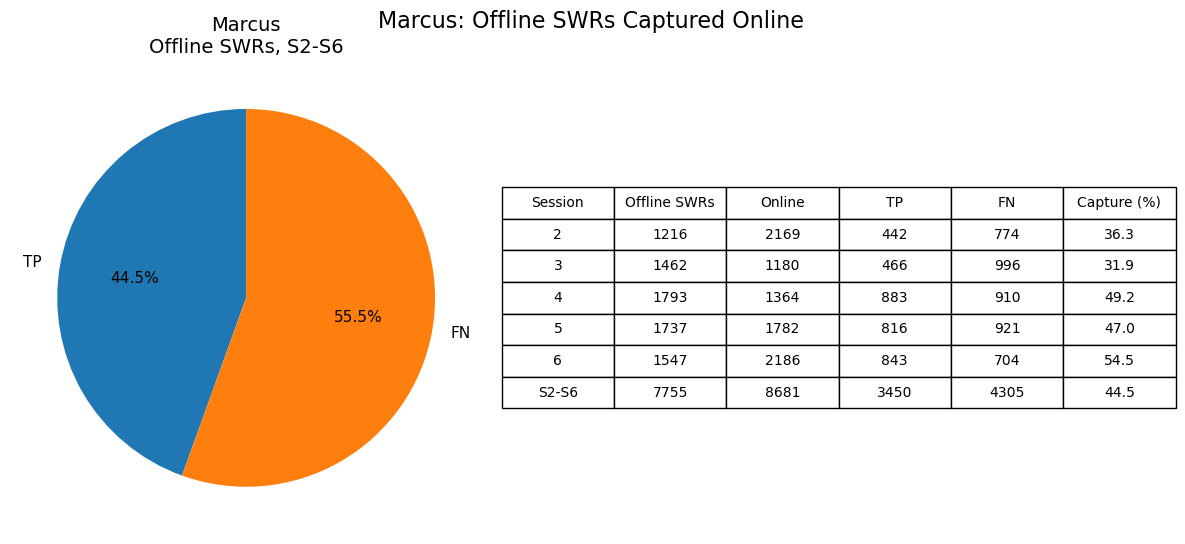

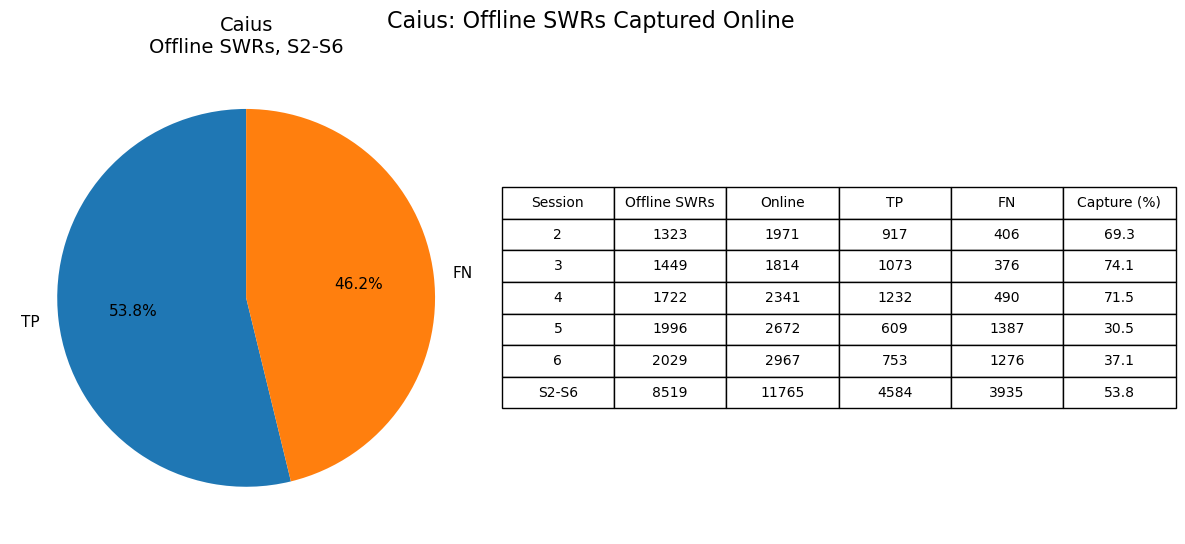

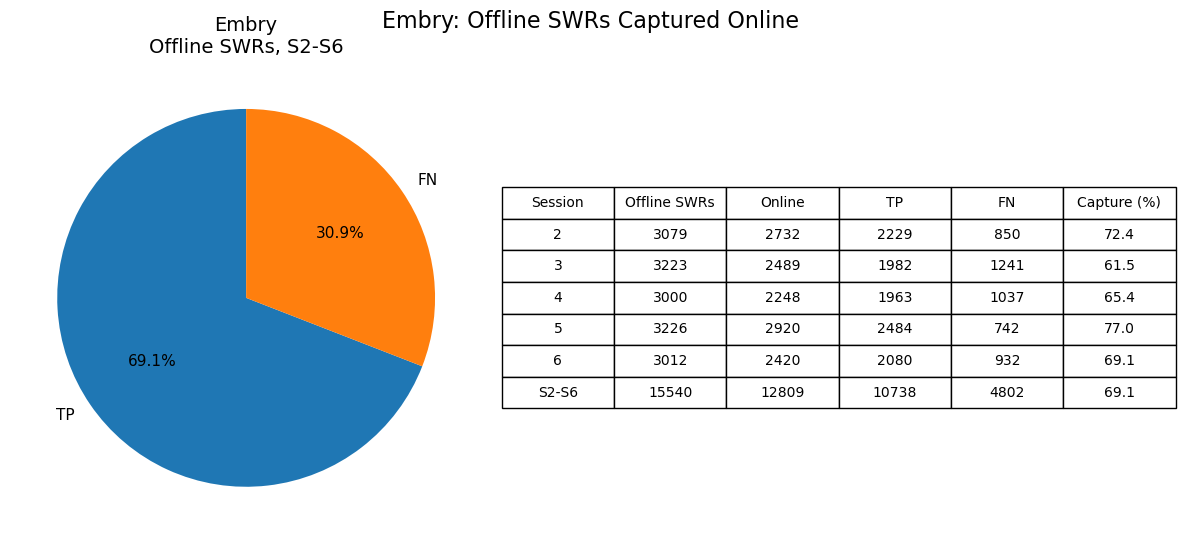

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Load data
# =====================================================

caius = pd.read_csv("caius_online_offline_stats.csv")
embry = pd.read_csv("embry_online_offline_stats.csv")
marcus = pd.read_csv("marcus_online_offline_stats.csv")

# =====================================================
# Standardize session number
# =====================================================

for df in [caius, embry, marcus]:
    df["Session"] = (
        df["session"]
        .str.extract(r"_s(\d+)")[0]
        .astype(int)
    )

# Standardize capture column
caius["Capture"] = caius["capture_pct"]
embry["Capture"] = embry["capture_pct"]
marcus["Capture"] = marcus["online_capture_pct"]

# =====================================================
# Function for one animal
# =====================================================

def make_animal_supplement(animal_name, df):

    # ---------------------------------------------
    # Exclude S1 because no laser was delivered
    # ---------------------------------------------
    laser_on = df[df["Session"] != 1].copy()

    # ---------------------------------------------
    # Total TP/FN across S2-S6
    # ---------------------------------------------
    total_tp = int(laser_on["TP"].sum())
    total_fn = int(laser_on["FN"].sum())

    total_offline = total_tp + total_fn

    capture_pct = (
        100 * total_tp / total_offline
        if total_offline > 0
        else 0
    )

    # ---------------------------------------------
    # Create figure
    # ---------------------------------------------
    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(12, 5.5),
        gridspec_kw={"width_ratios": [1, 1.4]}
    )

    # =============================================
    # LEFT: Pie chart
    # =============================================

    ax1.pie(
        [total_tp, total_fn],
        labels=["TP", "FN"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize": 11}
    )

    ax1.set_title(
        f"{animal_name}\n"
        f"Offline SWRs, S2-S6",
        fontsize=14
    )

    # =============================================
    # RIGHT: Statistics table
    # =============================================

    table_data = laser_on[
        [
            "Session",
            "offline_swr",
            "online_detection",
            "TP",
            "FN",
            "Capture"
        ]
    ].copy()

    table_data.columns = [
        "Session",
        "Offline SWRs",
        "Online",
        "TP",
        "FN",
        "Capture (%)"
    ]

    table_data["Capture (%)"] = (
        table_data["Capture (%)"].round(1)
    )

    # Add total row
    total_row = pd.DataFrame({
        "Session": ["S2-S6"],
        "Offline SWRs": [
            int(laser_on["offline_swr"].sum())
        ],
        "Online": [
            int(laser_on["online_detection"].sum())
        ],
        "TP": [total_tp],
        "FN": [total_fn],
        "Capture (%)": [round(capture_pct, 1)]
    })

    table_data = pd.concat(
        [table_data, total_row],
        ignore_index=True
    )

    ax2.axis("off")

    table = ax2.table(
        cellText=table_data.values,
        colLabels=table_data.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.7)

    # =============================================
    # Overall figure title
    # =============================================

    fig.suptitle(
        f"{animal_name}: Offline SWRs Captured Online",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


# =====================================================
# Generate three separate figures
# =====================================================

make_animal_supplement(
    "Marcus",
    marcus
)

make_animal_supplement(
    "Caius",
    caius
)

make_animal_supplement(
    "Embry",
    embry
)